# Análisis de la calidad del vino - UCI

## Análisis sin estandarización de las variables

Vamos a realizar el análisis mediante un modelo de regresión lineal múltiple, probando a hacerlo primero sin estandarizar las variables, y luego aplicando la estandarización.

Primero, importamos los módulos necesarios:

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


Descargamos el archivo en memoria y lo leemos directamente, creando un DataFrame, ya que es una funcionalidad que Pandas nos otorga:

In [79]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [80]:
for col in df.columns:
    print(f'\n- {col}:')
    print(df[col].describe())



- fixed acidity:
count    1599.000000
mean        8.319637
std         1.741096
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64

- volatile acidity:
count    1599.000000
mean        0.527821
std         0.179060
min         0.120000
25%         0.390000
50%         0.520000
75%         0.640000
max         1.580000
Name: volatile acidity, dtype: float64

- citric acid:
count    1599.000000
mean        0.270976
std         0.194801
min         0.000000
25%         0.090000
50%         0.260000
75%         0.420000
max         1.000000
Name: citric acid, dtype: float64

- residual sugar:
count    1599.000000
mean        2.538806
std         1.409928
min         0.900000
25%         1.900000
50%         2.200000
75%         2.600000
max        15.500000
Name: residual sugar, dtype: float64

- chlorides:
count    1599.000000
mean        0.087467
std         0.047065
min         0.012000
25%       

In [81]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [82]:
X = df.drop('quality', axis=1)
y = df['quality']
X, y

(      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
 0               7.4             0.700         0.00             1.9      0.076   
 1               7.8             0.880         0.00             2.6      0.098   
 2               7.8             0.760         0.04             2.3      0.092   
 3              11.2             0.280         0.56             1.9      0.075   
 4               7.4             0.700         0.00             1.9      0.076   
 ...             ...               ...          ...             ...        ...   
 1594            6.2             0.600         0.08             2.0      0.090   
 1595            5.9             0.550         0.10             2.2      0.062   
 1596            6.3             0.510         0.13             2.3      0.076   
 1597            5.9             0.645         0.12             2.0      0.075   
 1598            6.0             0.310         0.47             3.6      0.067   
 
       free su

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [84]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [85]:
y_pred = model.predict(X_test)

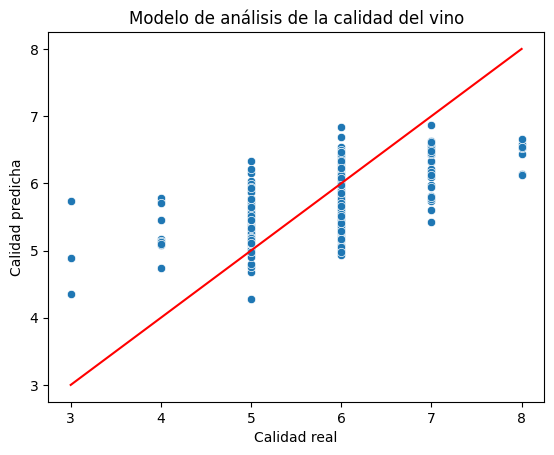

In [86]:
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Modelo de análisis de la calidad del vino')
plt.show()


In [87]:
mse_nosc = mean_squared_error(y_test, y_pred)
r2_nosc = r2_score(y_test, y_pred)
print("R2:", r2_nosc)
print("MSE: ", mse_nosc)


R2: 0.41331401883866026
MSE:  0.3999949392068255


## Análisis con estandarización de las variables 

In [88]:
from sklearn.preprocessing import StandardScaler

scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_sc = scaler_X.fit_transform(X)
y_sc = scaler_y.fit_transform(pd.DataFrame(y))
X_sc, y_sc

(array([[-0.52835961,  0.96187667, -1.39147228, ...,  1.28864292,
         -0.57920652, -0.96024611],
        [-0.29854743,  1.96744245, -1.39147228, ..., -0.7199333 ,
          0.1289504 , -0.58477711],
        [-0.29854743,  1.29706527, -1.18607043, ..., -0.33117661,
         -0.04808883, -0.58477711],
        ...,
        [-1.1603431 , -0.09955388, -0.72391627, ...,  0.70550789,
          0.54204194,  0.54162988],
        [-1.39015528,  0.65462046, -0.77526673, ...,  1.6773996 ,
          0.30598963, -0.20930812],
        [-1.33270223, -1.21684919,  1.02199944, ...,  0.51112954,
          0.01092425,  0.54162988]]),
 array([[-0.78782264],
        [-0.78782264],
        [-0.78782264],
        ...,
        [ 0.45084835],
        [-0.78782264],
        [ 0.45084835]]))

In [89]:
X_sc_train, X_sc_test, y_sc_train, y_sc_test = train_test_split(X_sc, y_sc, test_size=0.2, random_state=17)
model_sc = LinearRegression()
model_sc.fit(X_sc_train, y_sc_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [90]:
y_pred_sc = model_sc.predict(X_sc_test)

In [91]:
y_pred_nosc = scaler_y.inverse_transform(y_pred_sc)
len(y_pred_nosc)

320

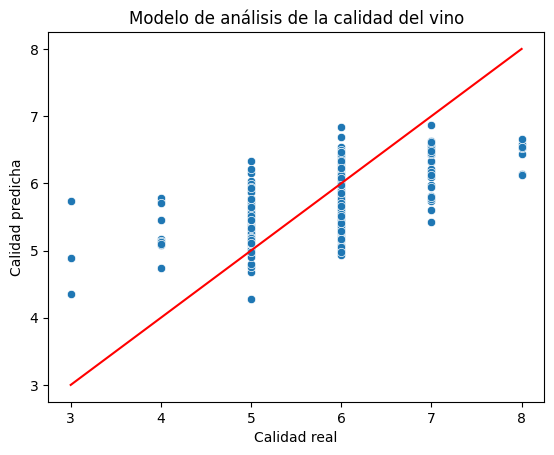

In [92]:
sns.scatterplot(x=y_test, y=y_pred_nosc.reshape(len(y_pred_nosc)))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Modelo de análisis de la calidad del vino')
plt.show()

In [93]:
mse_sc = mean_squared_error(y_test, y_pred_nosc)
r2_sc = r2_score(y_test, y_pred_nosc)
print("R2:", r2_sc)
print("MSE: ", mse_sc)

R2: 0.41331401883865737
MSE:  0.3999949392068275


## Intento VIF

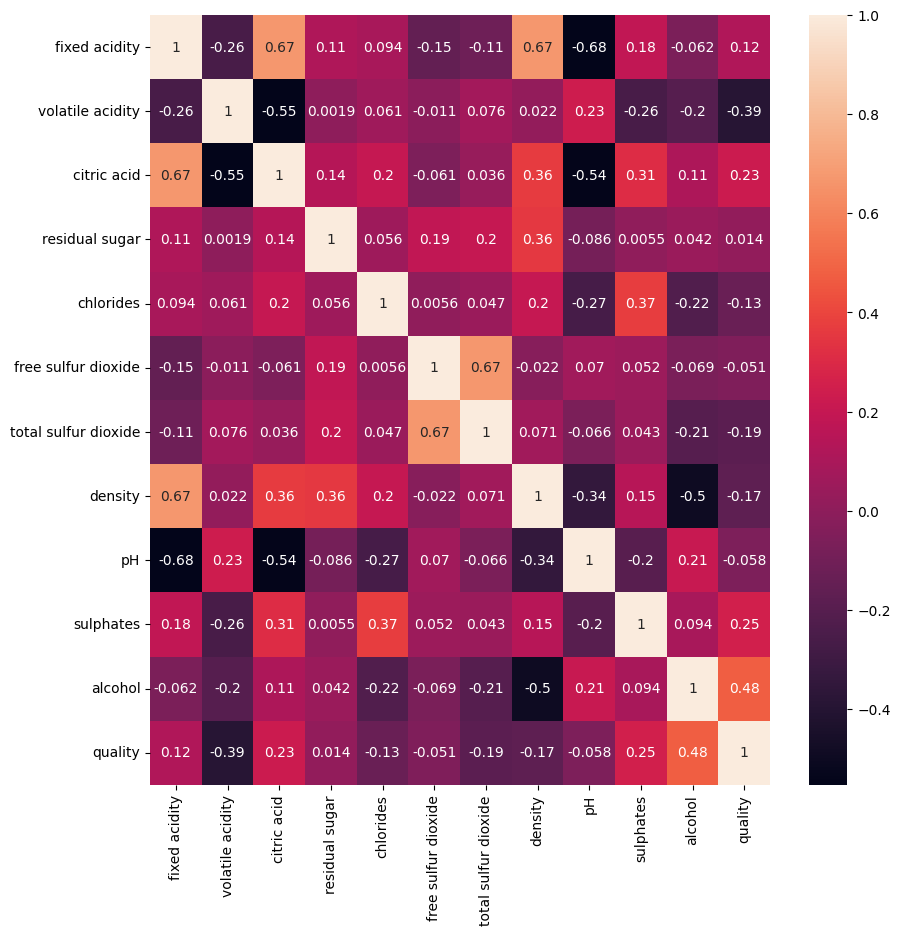

In [94]:
corr_matrix = df.corr()
corr_matrix
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, robust=True, annot=True)
plt.show()

In [95]:
high_corr_features = [(col1, col2, corr_matrix.loc[col1, col2])
                     for col1 in corr_matrix.columns
                     for col2 in corr_matrix.columns
                     if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > 0.6]

collinearity_df = pd.DataFrame(high_corr_features, columns=["Característica 1", "Característica 2", "Correlación"])
print("\Características altamente correlacionadas:\n", collinearity_df)

\Características altamente correlacionadas:
        Característica 1      Característica 2  Correlación
0         fixed acidity           citric acid     0.671703
1         fixed acidity               density     0.668047
2         fixed acidity                    pH    -0.682978
3           citric acid         fixed acidity     0.671703
4   free sulfur dioxide  total sulfur dioxide     0.667666
5  total sulfur dioxide   free sulfur dioxide     0.667666
6               density         fixed acidity     0.668047
7                    pH         fixed acidity    -0.682978


In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
print("\nFactor de Inflación de la Varianza (VIF) para cada característica:\n", vif_data)


Factor de Inflación de la Varianza (VIF) para cada característica:
                  Feature          VIF
0          fixed acidity    74.455312
1       volatile acidity    17.960867
2            citric acid     9.192549
3         residual sugar     4.664003
4              chlorides     6.641291
5    free sulfur dioxide     6.460603
6   total sulfur dioxide     6.605274
7                density  1528.154302
8                     pH  1078.171089
9              sulphates    22.462103
10               alcohol   147.616345
11               quality    77.728259


### PCA

In [97]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_sc)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("Varianza explicada por cada componente:", explained_variance)
print("Varianza acumulada:", cumulative_variance)

Varianza explicada por cada componente: [0.28173931 0.1750827  0.1409585  0.11029387 0.08720837 0.05996439
 0.05307193 0.03845061 0.0313311  0.01648483 0.00541439]
Varianza acumulada: [0.28173931 0.45682201 0.59778051 0.70807438 0.79528275 0.85524714
 0.90831906 0.94676967 0.97810077 0.99458561 1.        ]


In [98]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Usando los primeros {n_components} componentes principales")

Usando los primeros 9 componentes principales


In [99]:
X_pca_reduced = X_pca[:, :n_components]

In [123]:
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca_reduced, y_sc, test_size=0.2, random_state=17)
model_pca = LinearRegression()
model_pca.fit(X_pca_train, y_pca_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


320


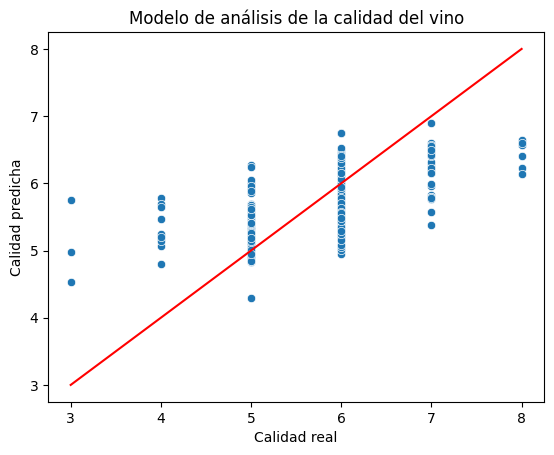

In [126]:
y_pred_pca = model_pca.predict(X_pca_test)
print(len(y_pred_pca))
y_pca_nosc = scaler_y.inverse_transform(y_pred_pca)
sns.scatterplot(x=y_test, y=y_pca_nosc.reshape(len(y_pca_nosc)))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Modelo de análisis de la calidad del vino')
plt.show()

In [128]:
mse_pca = mean_squared_error(y_test, y_pca_nosc)
r2_pca = r2_score(y_test, y_pca_nosc)

print("R2:", r2_pca)
print("MSE: ", mse_pca)

R2: 0.42302793128999683
MSE:  0.39337211891590695


quitemos pH, density

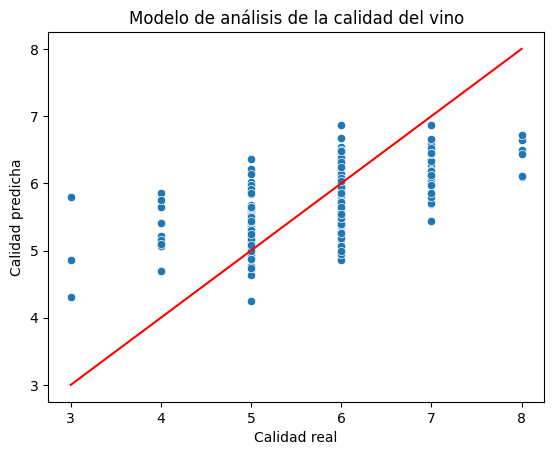

In [101]:
X_1 = df.drop(['quality', 'pH', 'density',], axis=1)

scaler_X_1 = StandardScaler()
X_sc_1 = scaler_X.fit_transform(X_1)

X_1_sc_train, X_1_sc_test, y_sc_train, y_sc_test = train_test_split(X_sc_1, y_sc, test_size=0.2, random_state=17)
model_sc_1 = LinearRegression()
model_sc_1.fit(X_1_sc_train, y_sc_train)

y_pred_sc_1 = model_sc_1.predict(X_1_sc_test)

y_pred_nosc_1 = scaler_y.inverse_transform(y_pred_sc_1)

sns.scatterplot(x=y_test, y=y_pred_nosc_1.reshape(len(y_pred_nosc_1)))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Modelo de análisis de la calidad del vino')
plt.show()

In [102]:
mse_sc_1 = mean_squared_error(y_test, y_pred_nosc_1)
r2_sc_1 = r2_score(y_test, y_pred_nosc_1)

print("R2:", r2_sc_1)
print("MSE: ", mse_sc_1)

R2: 0.4059094186582993
MSE:  0.4050433001598714


## Polinómica

In [103]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=1)
X_poly_train = poly.fit_transform(X_sc_train)
X_poly_test = poly.fit_transform(X_sc_test)

modelo_poly = LinearRegression()
modelo_poly.fit(X_poly_train, y_sc_train)

y_pred_poly = modelo_poly.predict(X_poly_test)

len(y_pred_poly)

mse_poly = mean_squared_error(y_sc_test, y_pred_poly)
r2_poly = r2_score(y_sc_test, y_pred_poly)
mse_poly, r2_poly
print("R2:", r2_poly)
print("MSE: ", mse_poly)

R2: 0.41331401883865726
MSE:  0.6137145696341959


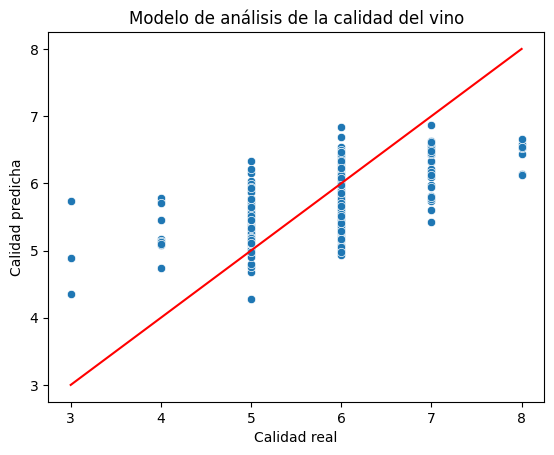

In [104]:
y_pred_poly_nosc = scaler_y.inverse_transform(y_pred_poly)

sns.scatterplot(x=y_test, y=y_pred_poly_nosc.reshape(len(y_pred_poly_nosc)))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Modelo de análisis de la calidad del vino')
plt.show()

320


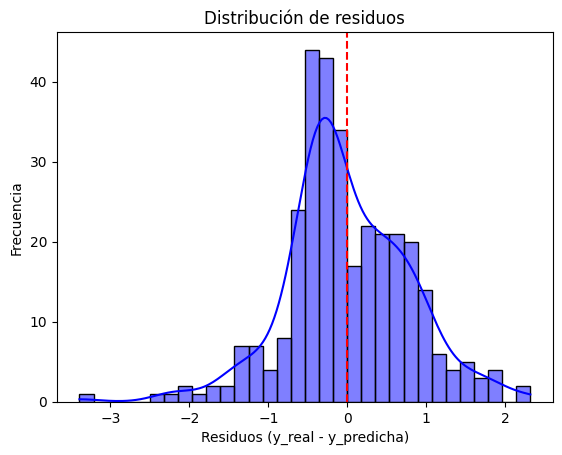

In [105]:
residuos = y_sc_test.reshape(len(y_sc_test)) - y_pred_poly.reshape(len(y_pred_poly))
print(len(residuos))
sns.histplot(residuos, bins=32, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribución de residuos")
plt.xlabel("Residuos (y_real - y_predicha)")
plt.ylabel("Frecuencia")
plt.show()

## Conclusiones

In [106]:
coef_df = pd.DataFrame({'Característica' : X_1.columns, 'Coeficiente' : model_sc_1.coef_.reshape(len(model_sc_1.coef_[0]))}).sort_values('Coeficiente', ascending=False)
coef_df

,Característica,Coeficiente
8,alcohol,0.373367
7,sulphates,0.166944
0,fixed acidity,0.116213
5,free sulfur dioxide,0.052015
3,residual sugar,0.014163
4,chlorides,-0.077329
2,citric acid,-0.081689
6,total sulfur dioxide,-0.097683
1,volatile acidity,-0.271535


In [107]:
coef_df_orig = pd.DataFrame({'Característica' : X.columns, 'Coeficiente' : model_sc.coef_.reshape(11)}).sort_values('Coeficiente', ascending=False)
coef_df_orig

,Característica,Coeficiente
10,alcohol,0.349676
9,sulphates,0.176848
0,fixed acidity,0.120256
5,free sulfur dioxide,0.056451
3,residual sugar,0.033768
8,pH,-0.053390
7,density,-0.060836
2,citric acid,-0.084218
4,chlorides,-0.089630
6,total sulfur dioxide,-0.109945


320


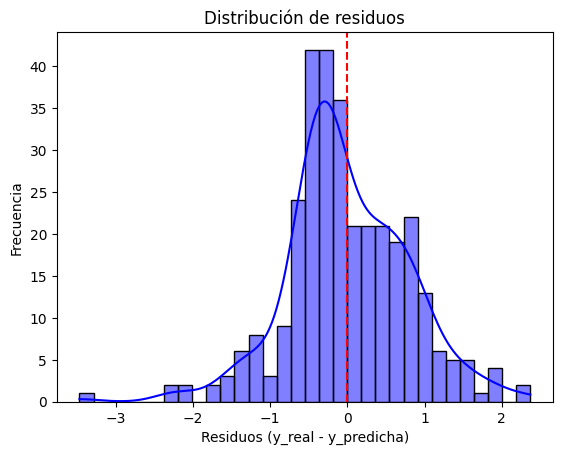

In [108]:
residuos = y_sc_test.reshape(len(y_sc_test)) - y_pred_sc_1.reshape(len(y_pred_nosc_1))
print(len(residuos))
sns.histplot(residuos, bins=32, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribución de residuos")
plt.xlabel("Residuos (y_real - y_predicha)")
plt.ylabel("Frecuencia")
plt.show()

## Bonus: árbol de decisión

In [159]:
from sklearn.tree import DecisionTreeRegressor


modelo_arbol = DecisionTreeRegressor(criterion='squared_error', random_state=17,
                                     max_depth=6, splitter='random',
                                     max_features=8)
modelo_arbol.fit(X_train, y_train)
y_arbol_pred = modelo_arbol.predict(X_test)
print("R2:", r2_score(y_test, y_arbol_pred))
print("MSE: ", mean_squared_error(y_test, y_arbol_pred))

R2: 0.380897388696118
MSE:  0.4220961797673879


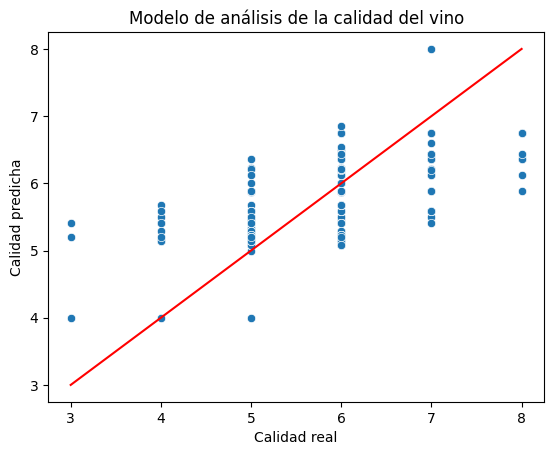

In [110]:
sns.scatterplot(x=y_test, y=y_arbol_pred.reshape(len(y_arbol_pred)))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Modelo de análisis de la calidad del vino')
plt.show()

320


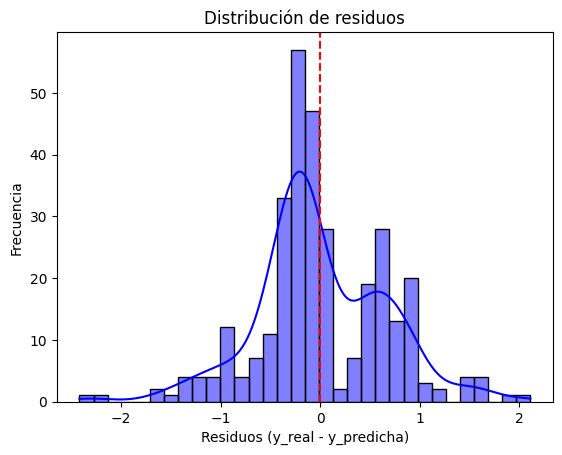

: 

In [ ]:
residuos = y_test - y_arbol_pred.reshape(len(y_arbol_pred))
print(len(residuos))
sns.histplot(residuos, bins=32, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribución de residuos")
plt.xlabel("Residuos (y_real - y_predicha)")
plt.ylabel("Frecuencia")
plt.show()

In [156]:
modelo_arbol = DecisionTreeRegressor(criterion='friedman_mse', random_state=17,
                                     max_depth=5, splitter='random',
                                     max_features=9)
modelo_arbol.fit(X_1_sc_train, y_sc_train)
y_arbol_pred = modelo_arbol.predict(X_1_sc_test)
print("R2:", r2_score(y_sc_test, y_arbol_pred))
print("MSE: ", mean_squared_error(y_sc_test, y_arbol_pred))

R2: 0.34068708829873884
MSE:  0.6896874185710805


320


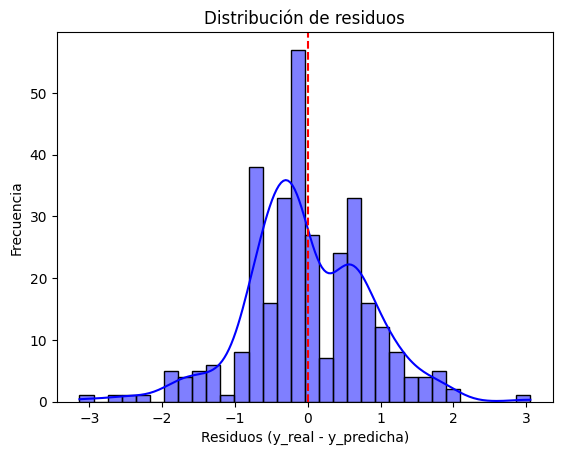

In [151]:
residuos = y_sc_test.reshape(len(y_sc_test)) - y_arbol_pred.reshape(len(y_arbol_pred))
print(len(residuos))
sns.histplot(residuos, bins=32, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribución de residuos")
plt.xlabel("Residuos (y_real - y_predicha)")
plt.ylabel("Frecuencia")
plt.show()